# TU Berlin Final Project - F1 data analysis

## Project Overview
This project analyses F1 telemetry data from the 2026 Pre-Season 
testing session in Bahrain. Using second-by-second data for 18 drivers,
we explore lap times, speed, throttle, brake and RPM patterns
to answer 15 analytical questions across 5 groups.

**Dataset:** All_Laps_5_June_2026.csv
**Session:** Pre-Season 2026 — Bahrain — Day 1
**Drivers:** 18
**Total data points:** ~145,000

## CLEANING and PREPARING THE DATA

##### dataset : "C:\Users\ebebo\Desktop\TUcourseMaterial\Final project\archive\All Laps - 5 June 2026.csv"

In [16]:
import pandas as pd
import json
import plotly.express as px

# uploading the file
df = pd.read_csv(r"C:\Users\ebebo\Desktop\TUcourseMaterial\Final project\archive\All Laps - 5 June 2026.csv")

# explode the JSON of the telemetry --> divide the single column called interval_data
df['interval_data'] = df['interval_data'].apply(lambda x : json.loads(x) if pd.notnull(x) else [])
df_exploded = df.explode('interval_data').reset_index(drop=True)
telemetry_columns = pd.json_normalize(df_exploded['interval_data'])

# concatenating to obtain the final dataframe (all informations)
final_df = pd.concat([df_exploded.drop(columns=['interval_data']), telemetry_columns], axis=1)
final_df[0:25]

,season,event_name,circuit,session_type,driver_code,lap_number,lap_time_sec_total,t,rpm,gear,brake,speed,throttle
0,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,0,10818,8,False,307,99
1,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,1,10975,8,False,313,99
2,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,2,10936,8,False,313,99
3,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,3,10859,8,False,310,99
4,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,4,10763,8,False,307,99
5,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,5,10664,8,False,305,99
6,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,6,10592,8,False,303,99
7,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,7,9629,8,True,220,0
8,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,8,10552,3,True,149,0
9,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,9,7682,2,True,95,0


In [17]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145082 entries, 0 to 145081
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   season              145082 non-null  int64  
 1   event_name          145082 non-null  object 
 2   circuit             145082 non-null  object 
 3   session_type        145082 non-null  object 
 4   driver_code         145082 non-null  object 
 5   lap_number          145082 non-null  int64  
 6   lap_time_sec_total  145082 non-null  float64
 7   t                   145082 non-null  int64  
 8   rpm                 145082 non-null  int64  
 9   gear                145082 non-null  int64  
 10  brake               145082 non-null  bool   
 11  speed               145082 non-null  int64  
 12  throttle            145082 non-null  int64  
dtypes: bool(1), float64(1), int64(7), object(4)
memory usage: 13.4+ MB


In [18]:
# converting brake (bool --> int (0/1))  [ gear = int, throttle = int]
final_df['brake'] = final_df['brake'].astype(int)
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145082 entries, 0 to 145081
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   season              145082 non-null  int64  
 1   event_name          145082 non-null  object 
 2   circuit             145082 non-null  object 
 3   session_type        145082 non-null  object 
 4   driver_code         145082 non-null  object 
 5   lap_number          145082 non-null  int64  
 6   lap_time_sec_total  145082 non-null  float64
 7   t                   145082 non-null  int64  
 8   rpm                 145082 non-null  int64  
 9   gear                145082 non-null  int64  
 10  brake               145082 non-null  int64  
 11  speed               145082 non-null  int64  
 12  throttle            145082 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 14.4+ MB


In [19]:
final_df.head()

,season,event_name,circuit,session_type,driver_code,lap_number,lap_time_sec_total,t,rpm,gear,brake,speed,throttle
0,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,0,10818,8,0,307,99
1,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,1,10975,8,0,313,99
2,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,2,10936,8,0,313,99
3,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,3,10859,8,0,310,99
4,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,4,10763,8,0,307,99


In [20]:
# add significant columns (will be used)

# flag --> best lap time (it says if it's the best lap time or not)
best_lap_times = final_df.groupby('driver_code')['lap_time_sec_total'].transform('min')
final_df['is_best_lap'] = (final_df['lap_time_sec_total'] == best_lap_times)

# flag --> throttle opened (> 0)
final_df['throttle_open'] = final_df['throttle'] > 0

# flag --> active braking (true / false)
final_df['is_braking'] = (final_df['brake'] == 1)

final_df.head()

,season,event_name,circuit,session_type,driver_code,lap_number,lap_time_sec_total,t,rpm,gear,brake,speed,throttle,is_best_lap,throttle_open,is_braking
0,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,0,10818,8,0,307,99,False,True,False
1,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,1,10975,8,0,313,99,False,True,False
2,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,2,10936,8,0,313,99,False,True,False
3,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,3,10859,8,0,310,99,False,True,False
4,2026,Pre-Season Testing,Bahrain International Circuit,Day_1,OCO,8,99.848,4,10763,8,0,307,99,False,True,False


In [21]:
# CLEANING --> costant columns
# save metadata before dropping them (useful for titles after)
SEASON       = final_df['season'].iloc[0]        # 2026
EVENT_NAME   = final_df['event_name'].iloc[0]    # Pre-Season
CIRCUIT      = final_df['circuit'].iloc[0]       # Bahrain
SESSION_TYPE = final_df['session_type'].iloc[0]  # Day_1

# print(f"Sessione: {EVENT_NAME} {SEASON} — {CIRCUIT} ({SESSION_TYPE})")
# → Pre-Season 2026 — Bahrain (Day_1)

# now drop the costants
cols_to_drop = ['season', 'event_name', 'circuit', 'session_type']
final_df = final_df.drop(columns=cols_to_drop)

final_df.head()

,driver_code,lap_number,lap_time_sec_total,t,rpm,gear,brake,speed,throttle,is_best_lap,throttle_open,is_braking
0,OCO,8,99.848,0,10818,8,0,307,99,False,True,False
1,OCO,8,99.848,1,10975,8,0,313,99,False,True,False
2,OCO,8,99.848,2,10936,8,0,313,99,False,True,False
3,OCO,8,99.848,3,10859,8,0,310,99,False,True,False
4,OCO,8,99.848,4,10763,8,0,307,99,False,True,False


In [22]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145082 entries, 0 to 145081
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   driver_code         145082 non-null  object 
 1   lap_number          145082 non-null  int64  
 2   lap_time_sec_total  145082 non-null  float64
 3   t                   145082 non-null  int64  
 4   rpm                 145082 non-null  int64  
 5   gear                145082 non-null  int64  
 6   brake               145082 non-null  int64  
 7   speed               145082 non-null  int64  
 8   throttle            145082 non-null  int64  
 9   is_best_lap         145082 non-null  bool   
 10  throttle_open       145082 non-null  bool   
 11  is_braking          145082 non-null  bool   
dtypes: bool(3), float64(1), int64(7), object(1)
memory usage: 10.4+ MB


In [23]:
import plotly.express as px
import plotly.io as pio

# define the theme as default
pio.templates.default = 'plotly_white'

## ANSWERING QUESTIONS (15) --> VISUALIZATION

### Group 1 — Lap Times & Performance (1-4)


#### (1) LAP TIMES & PERFORMANCE

###### Best lap time achieved by each driver across all sessions 

In [24]:
# lists of the best laps (classified from the best one)
best_laps = (final_df.groupby('driver_code')['lap_time_sec_total']
                     .min()
                     .reset_index()
                     .rename(columns={'lap_time_sec_total':'best_lap_time'})
                     .sort_values('best_lap_time'))
best_laps.reset_index(drop=True)

,driver_code,best_lap_time
0,NOR,94.669
1,VER,94.798
2,LEC,95.190
3,OCO,95.578
4,PIA,95.602
5,RUS,96.108
6,HAM,96.433
7,HUL,96.861
8,ALB,97.437
9,ANT,97.629


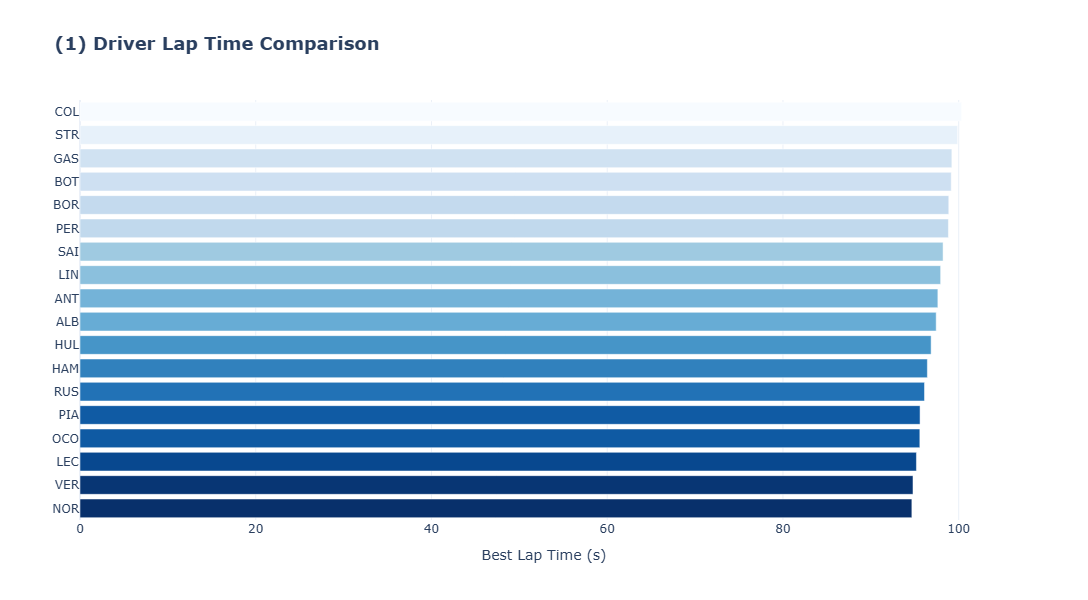

In [25]:
# Create a horizontal bar chart to compare best lap times across drivers
# I use orientation='h' because driver names read better on the y-axis

fig1 = px.bar(
    data_frame=best_laps,
    x='best_lap_time',        # lap time on x-axis (numerical value)
    y='driver_code',          # drivers on y-axis (categorical)
    orientation='h',          # horizontal bars
    title='(1) Driver Lap Time Comparison',
    labels={'best_lap_time': 'Best Lap Time (s)',
            'driver_code': ''},   # remove y-axis label, names are self-explanatory
    color='best_lap_time',    # color bars by lap time value
    color_continuous_scale=px.colors.sequential.Blues_r,  # darker = faster
    width=900,
    height=600
)

# Layout customizations
fig1.update_layout(
    title_font=dict(size=18, weight='bold'),
    coloraxis_showscale=False,   # hide color scale bar, not needed here
    yaxis=dict(categoryorder='total ascending')  # sort from slowest to fastest
)

fig1.show()

#### (2) LAP TIME EVOLUTION

###### Does each driver consistently improve their lap time over successive laps?

In [26]:
import numpy as np
# Q2 — Lap time evolution with CI
lap_evo_stats = (final_df[final_df['lap_time_sec_total'] < 200]
                 .groupby(['driver_code', 'lap_number'])['lap_time_sec_total']
                 .agg(mean_time='mean', std_time='std', n='count')
                 .reset_index())
lap_evo_stats['ci'] = 1.96 * (lap_evo_stats['std_time'] / np.sqrt(lap_evo_stats['n']))
lap_evo_stats

,driver_code,lap_number,mean_time,std_time,n,ci
0,ALB,2,99.416,0.0,100,0.0
1,ALB,3,145.080,0.0,146,0.0
2,ALB,4,132.508,0.0,133,0.0
3,ALB,6,99.208,0.0,100,0.0
4,ALB,7,140.604,0.0,141,0.0
...,...,...,...,...,...,...
880,VER,132,97.592,0.0,98,0.0
881,VER,133,97.540,0.0,98,0.0
882,VER,134,97.788,0.0,98,0.0
883,VER,135,128.666,0.0,129,0.0


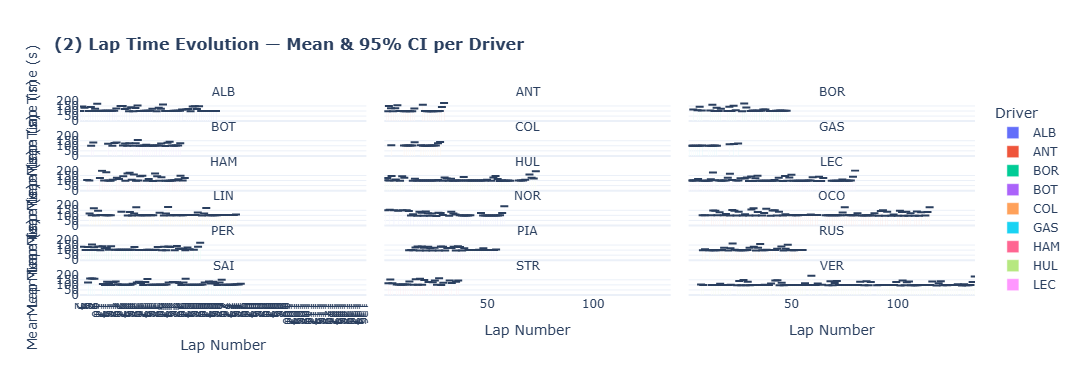

In [28]:
# Line chart to show how each driver's lap time evolves over successive laps
# Each driver gets its own line colored differently

fig2 = px.bar(
    data_frame=lap_evo_stats,
    x='lap_number', y='mean_time',
    error_y='ci',
    color='driver_code',
    barmode='group',
    facet_col='driver_code',   # ← un pannello per ogni pilota
    facet_col_wrap=3,          # ← 3 pannelli per riga
    title='(2) Lap Time Evolution — Mean & 95% CI per Driver',
    labels={'mean_time': 'Mean Lap Time (s)',
            'lap_number': 'Lap Number',
            'driver_code': 'Driver'})
fig2.update_layout(
    title_font=dict(size=16, weight='bold'),
    xaxis=dict(tickmode='linear', dtick=1))
fig2.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
fig2.show()

#### (3) DRIVER CONSISTENCY

###### Delta between each driver's fastest and slowest lap as a measure of consistency

In [76]:
# difference between best and worst lap of each pilot
# creating a new dataFrame with best and worst lap
consistency = (final_df[final_df['lap_time_sec_total'] < 200]
               .groupby('driver_code')['lap_time_sec_total']
               .agg(best_lap='min', worst_lap='max')
               .reset_index())

consistency['delta'] = (consistency['worst_lap'] - consistency['best_lap']).round(2)
consistency = consistency.sort_values('delta')
consistency.reset_index(drop=True)

,driver_code,best_lap,worst_lap,delta
0,GAS,99.221,121.960,22.74
1,COL,100.330,136.763,36.43
2,PIA,95.602,138.293,42.69
3,BOT,99.150,157.301,58.15
4,STR,99.883,165.718,65.83
5,SAI,98.221,164.274,66.05
6,RUS,96.108,164.417,68.31
7,ALB,97.437,171.391,73.95
8,PER,98.828,173.149,74.32
9,BOR,98.871,174.808,75.94


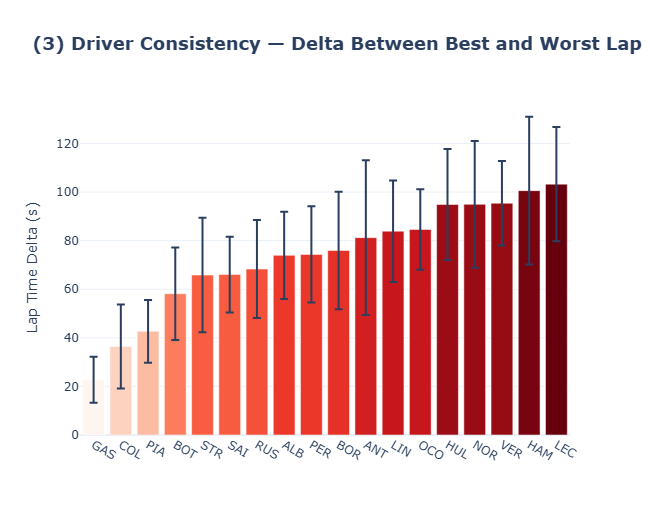

In [77]:
import numpy as np

# add standard error and CI to consistency DataFrame
consistency['se'] = consistency['delta'] / np.sqrt(
    final_df.groupby('driver_code')['lap_number']
    .nunique()
    .reset_index()['lap_number'])

consistency['ci'] = 1.96 * consistency['se']

# bar chart with error bars
fig3 = px.bar(
    data_frame=consistency,
    x='driver_code',
    y='delta',
    error_y='ci',
    color='delta',
    color_continuous_scale=px.colors.sequential.Reds,
    title='(3) Driver Consistency — Delta Between Best and Worst Lap',
    labels={'driver_code': '',
            'delta': 'Lap Time Delta (s)'},
    width=1000,
    height=500
)

fig3.update_layout(
    title_font=dict(size=18, weight='bold'),
    coloraxis_showscale=False,
    xaxis=dict(categoryorder='total ascending')
)

fig3.show()

#### (4) Driver Performance Overview

###### Best lap time vs top speed vs consistency — each bubble represents a driver

In [40]:
speed_analysis = (final_df.groupby('driver_code')['speed']
                  .agg(max_speed='max', min_speed='min', avg_speed='mean')
                  .reset_index()
                  .sort_values('max_speed', ascending=False))

speed_analysis['avg_speed'] = speed_analysis['avg_speed'].round(2)

bubble_df = (best_laps
             .merge(speed_analysis[['driver_code', 'max_speed']], on='driver_code')
             .merge(consistency[['driver_code', 'delta']], on='driver_code'))

bubble_df

,driver_code,best_lap_time,max_speed,delta
0,NOR,94.669,330,830.70
1,VER,94.798,343,885.27
2,LEC,95.190,331,894.55
3,OCO,95.578,332,754.63
4,PIA,95.602,330,698.30
5,RUS,96.108,332,68.31
6,HAM,96.433,332,704.43
7,HUL,96.861,322,786.82
8,ALB,97.437,324,869.20
9,ANT,97.629,326,81.24


In [41]:
fig4 = px.scatter(
    data_frame=bubble_df,
    x='best_lap_time',        # asse X → chi è più veloce?
    y='max_speed',            # asse Y → chi va più forte?
    size='delta',             # dimensione bolla → consistenza
    color='driver_code',      # un colore per pilota
    hover_name='driver_code', # mostra il nome al passaggio del mouse
    title='(4) Driver Performance Overview',
    labels={'best_lap_time': 'Best Lap Time (s)',
            'max_speed': 'Top Speed (km/h)',
            'delta': 'Consistency (s)',
            'driver_code': 'Driver'},
    size_max=40,              # dimensione massima delle bolle
    width=1000,
    height=600
)

fig4.update_layout(
    title_font=dict(size=18, weight='bold'),
)

fig4.show()

### Group 2 — Speed Analysis (5-7)


#### (5) Top and Average Speed Per Driver

###### Maximum and average speed recorded for each driver throughout the session

In [74]:
speed_analysis_full = (final_df[final_df['gear'] > 0]
                  .groupby('driver_code')['speed']
                  .agg(max_speed='max', avg_speed='mean')
                  .reset_index())

speed_analysis_full['avg_speed'] = speed_analysis_full['avg_speed'].round(2)
speed_analysis_full

,driver_code,max_speed,avg_speed
0,ALB,324,170.51
1,ANT,326,175.72
2,BOR,319,173.47
3,HAM,332,158.79
4,HUL,322,170.40
5,LEC,331,175.39
6,LIN,338,176.40
7,NOR,330,166.64
8,OCO,332,166.09
9,PER,211,139.51


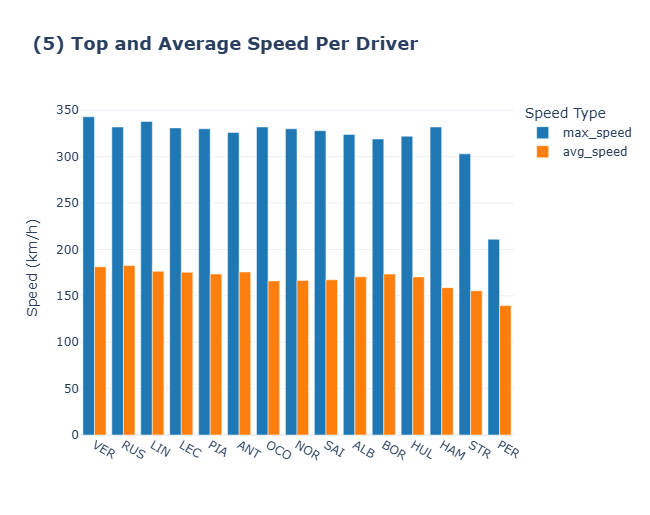

In [75]:
# transform it into long format --> function .melt()
speed_long = pd.melt(
    speed_analysis_full[['driver_code', 'max_speed', 'avg_speed']],
    id_vars='driver_code',
    var_name='speed_type',
    value_name='speed'
)

fig5 = px.bar(
    data_frame=speed_long,
    x='driver_code',
    y='speed',
    color='speed_type',
    barmode='group',
    title='(5) Top and Average Speed Per Driver',
    labels={'driver_code': '',
            'speed': 'Speed (km/h)',
            'speed_type': 'Speed Type'},
    color_discrete_map={'max_speed': '#1f77b4',
                        'avg_speed': '#ff7f0e'},
    width=1100,
    height=500
)

fig5.update_layout(
    title_font=dict(size=18, weight='bold'),
    xaxis=dict(categoryorder='total descending')
)

fig5.show()

#### (6) SPEED DISTRIBUTION FOR EACH PILOT

###### Time spent by each driver sustaining specific speed ranges (0-100, 100-200, 200-300, 300+ km/h)

In [44]:
# define speed zones
speed_bins = [0, 100, 200, 300, 400]
speed_labels = ['0-100', '100-200', '200-300', '300+']

# creating a new column with the speed zone
final_df['speed_range'] = pd.cut(final_df['speed'], bins=speed_bins, labels=speed_labels)

# count the rows (seconds) for each pilot in each range
speed_dist = (final_df.groupby(['driver_code', 'speed_range'], observed=True)
                      .size()
                      .reset_index()
                      .rename(columns={0:'seconds'}))
speed_dist

,driver_code,speed_range,seconds
0,ALB,0-100,1520
1,ALB,100-200,4645
2,ALB,200-300,2980
3,ALB,300+,166
4,ANT,0-100,428
5,ANT,100-200,1258
6,ANT,200-300,957
7,ANT,300+,126
8,BOR,0-100,994
9,BOR,100-200,2460


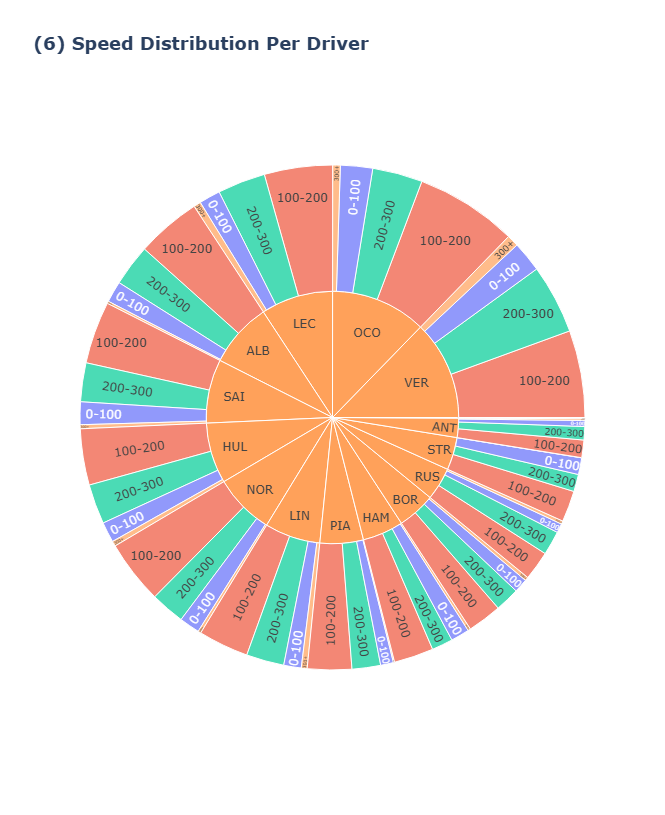

In [47]:
# aggiungi questa riga nel DataFrame speed_dist
speed_dist['speed_range'] = speed_dist['speed_range'].astype(str)

fig6 = px.sunburst(
    data_frame=speed_dist,
    path=['driver_code', 'speed_range'],
    values='seconds',
    color='speed_range',
    color_discrete_map={'0-100':'#636EFA', '100-200':'#EF553B', '200-300':'#00CC96', '300+':'#FFA15A'},
    title='(6) Speed Distribution Per Driver',
    width=800,
    height=800
)

fig6.update_layout(
    title_font=dict(size=18, weight='bold'))

fig6.update_traces(
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Seconds: %{value}<br>"
        "Share of total: %{percentRoot:.1%}"
        "<extra></extra>"
    )
)

fig6.show()

#### (7) AVERAGE SPEED PER GEAR

###### Average speed achieved in each gear across all drivers and laps

In [49]:
# want to discover the average speed for each gear
speed_per_gear = (final_df[final_df['gear'] > 0]
                      .groupby('gear')['speed']
                      .mean()
                      .reset_index()
                      .rename(columns={'speed':'avg_speed'}))

speed_per_gear['avg_speed'] = speed_per_gear['avg_speed'].round(2)
speed_per_gear

,gear,avg_speed
0,1,61.55
1,2,94.77
2,3,129.93
3,4,164.60
4,5,201.23
5,6,233.49
6,7,269.53
7,8,293.97


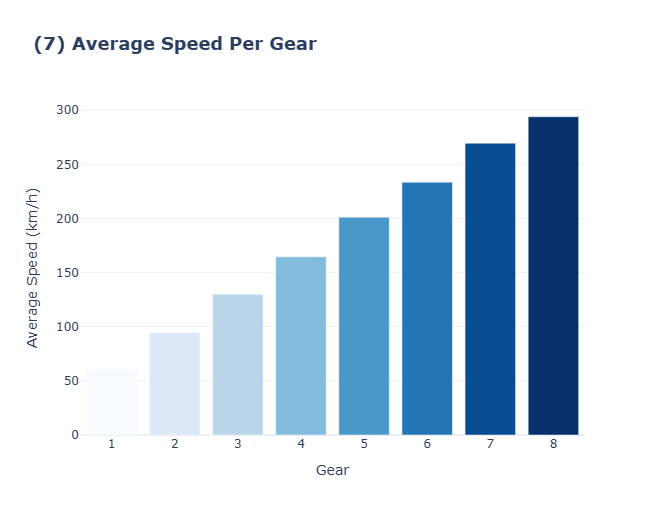

In [51]:
fig7 = px.bar(
    data_frame=speed_per_gear,
    x='gear',
    y='avg_speed',
    color='avg_speed',
    color_continuous_scale=px.colors.sequential.Blues,
    title='(7) Average Speed Per Gear',
    labels={'gear':'Gear', 'avg_speed':'Average Speed (km/h)'}, 
    width=700,
    height=500
)

fig7.update_layout(
    title_font=dict(size=18, weight='bold'),
    coloraxis_showscale=False,
    xaxis=dict(tickmode='linear', dtick=1)
)

fig7.show()

### Group 3 — Throttle & Brake (8-10)


#### (8) THROTTLE OPEN PERCENTAGE

###### Percentage of lap time spent with the throttle engaged (throttle > 0) per driver

In [53]:
perc_throttle_open = (final_df.groupby('driver_code')['throttle_open']
                              .mean() * 100).round(2).reset_index()
perc_throttle_open.rename(columns={'throttle_open':'throttle_pct'}, inplace=True)
perc_throttle_open.sort_values('throttle_pct', ascending=False, inplace=True)
perc_throttle_open.reset_index(drop=True, inplace=True)
perc_throttle_open

,driver_code,throttle_pct
0,HAM,78.37
1,LEC,77.46
2,ANT,75.14
3,STR,75.00
4,ALB,74.91
5,OCO,74.22
6,PIA,73.79
7,RUS,73.70
8,SAI,73.62
9,PER,72.24


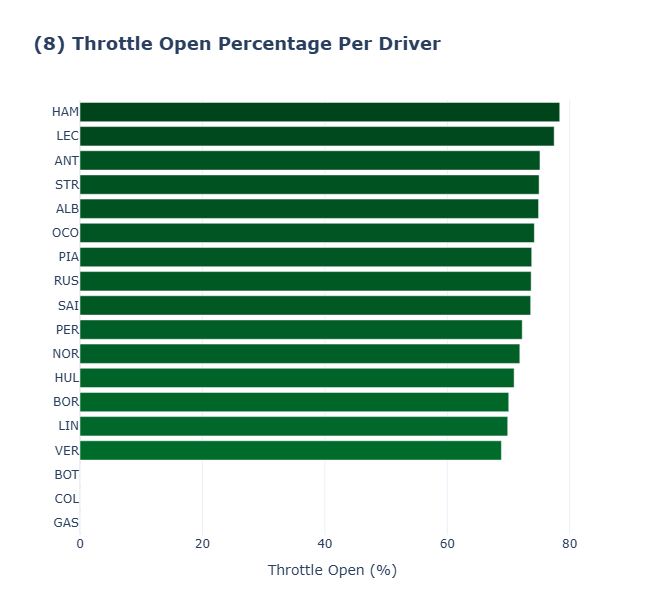

In [54]:
fig8 = px.bar(
    data_frame=perc_throttle_open,
    x='throttle_pct',
    y='driver_code',
    orientation='h',
    color='throttle_pct',
    color_continuous_scale=px.colors.sequential.Greens,
    title='(8) Throttle Open Percentage Per Driver',
    labels={'throttle_pct': 'Throttle Open (%)',
            'driver_code': ''},
    width=900,
    height=600
)

fig8.update_layout(
    title_font=dict(size=18, weight='bold'),
    coloraxis_showscale=False,
    yaxis=dict(categoryorder='total ascending')
)

fig8.show()

#### (9) BRAKING PERCENTAGE

###### Percentage of lap time spent braking (brake == 1) per driver

In [55]:
perc_brake_open = (final_df.groupby('driver_code')['is_braking']
                           .mean() * 100).round(2).reset_index()
perc_brake_open.rename(columns={'is_braking':'braking_pct'}, inplace=True)
perc_brake_open.sort_values('braking_pct', ascending=False, inplace=True)
perc_brake_open.reset_index(drop=True, inplace=True)
perc_brake_open

,driver_code,braking_pct
0,PER,71.92
1,NOR,31.02
2,STR,29.07
3,ALB,28.46
4,HAM,27.66
5,PIA,27.18
6,OCO,26.54
7,LIN,25.91
8,SAI,25.56
9,LEC,24.98


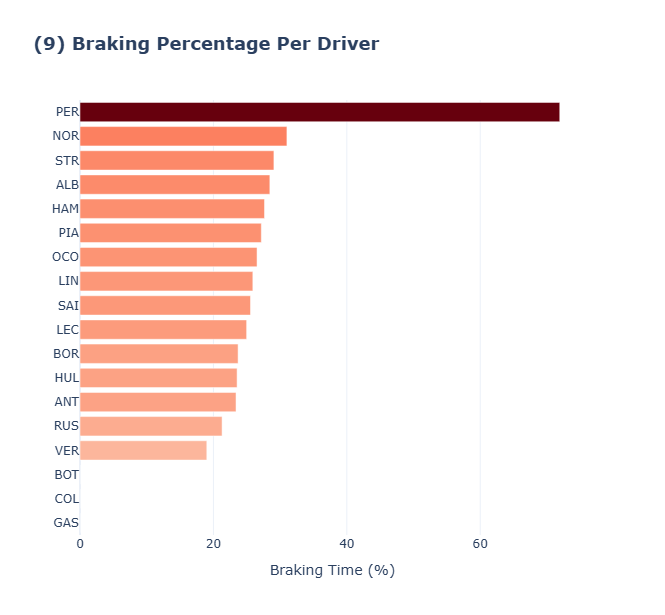

In [56]:
fig9 = px.bar(
    data_frame=perc_brake_open,
    x='braking_pct',
    y='driver_code',
    orientation='h',
    color='braking_pct',
    color_continuous_scale=px.colors.sequential.Reds,
    title='(9) Braking Percentage Per Driver',
    labels={'braking_pct': 'Braking Time (%)',
            'driver_code': ''},
    width=900,
    height=600
)

fig9.update_layout(
    title_font=dict(size=18, weight='bold'),
    coloraxis_showscale=False,
    yaxis=dict(categoryorder='total ascending')
)

fig9.show()

#### (10) DRIVING STYLE COMPARISON

###### Second-by-second throttle and brake telemetry during each driver's fastest lap

In [57]:
driving_style = final_df.loc[final_df['is_best_lap'] == True][['driver_code', 't', 'throttle', 'brake', 'speed']].reset_index(drop=True)

driving_style

,driver_code,t,throttle,brake,speed
0,OCO,0,98,0,292
1,OCO,1,99,0,306
2,OCO,2,98,0,317
3,OCO,3,99,0,325
4,OCO,4,98,0,327
...,...,...,...,...,...
1756,ANT,93,100,0,220
1757,ANT,94,100,0,249
1758,ANT,95,100,0,261
1759,ANT,96,100,0,266


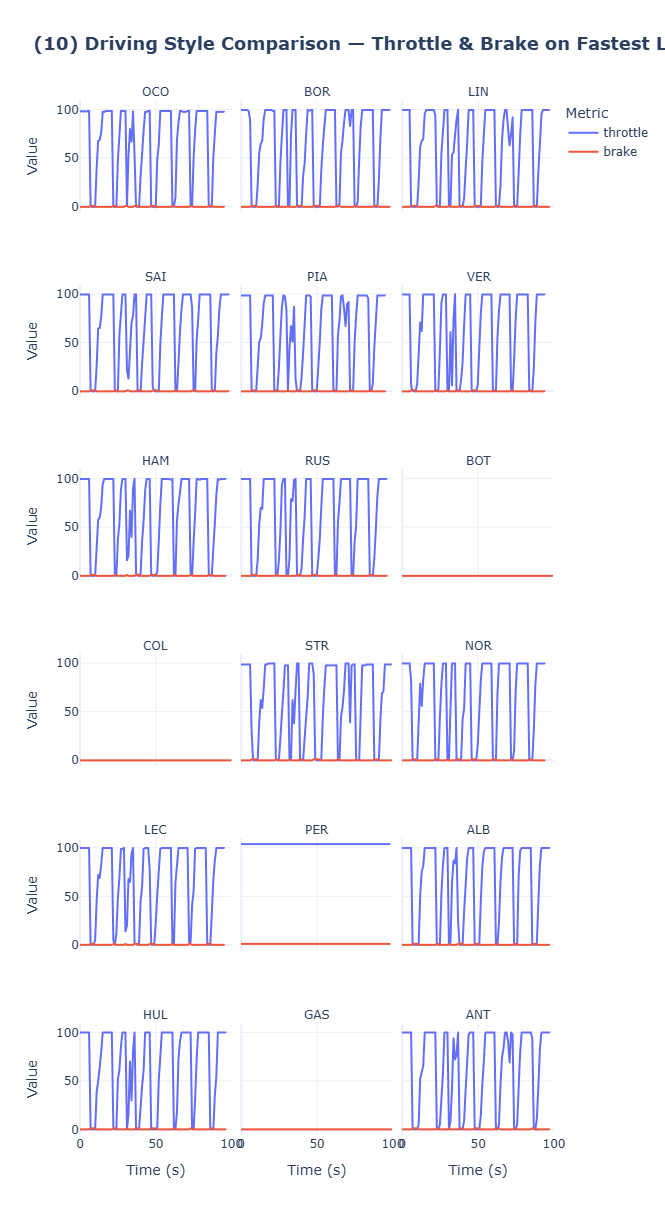

In [60]:
# trasforma in formato long per mostrare throttle e brake insieme
driving_style_long = pd.melt(
    driving_style,
    id_vars=['driver_code', 't'],
    value_vars=['throttle', 'brake'],
    var_name='metric',
    value_name='value'
)

fig10 = px.line(
    data_frame=driving_style_long,
    x='t',
    y='value',
    color='metric',            # una linea per throttle, una per brake
    facet_col='driver_code',   # un pannello per ogni pilota
    facet_col_wrap=3,          # 3 pannelli per riga
    title='(10) Driving Style Comparison — Throttle & Brake on Fastest Lap',
    labels={'t': 'Time (s)',
            'value': 'Value',
            'metric': 'Metric'},
    width=1400,
    height=1200
)

fig10.update_layout(title_font=dict(size=18, weight='bold'))
fig10.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

fig10.show()

### Group 4 — RPM & Gear Telemetry (11-13)


#### (11) High RPM vs High Throttle Correlation

###### Analyzing the relationship between peak RPM and throttle engagement across all laps

In [61]:
rpm_vs_throttle = final_df[final_df['gear'] > 0][['driver_code', 'rpm', 'throttle']].reset_index(drop=True)

rpm_vs_throttle

,driver_code,rpm,throttle
0,OCO,10818,99
1,OCO,10975,99
2,OCO,10936,99
3,OCO,10859,99
4,OCO,10763,99
...,...,...,...
112991,ANT,10950,100
112992,ANT,11081,100
112993,ANT,12108,100
112994,ANT,11309,100


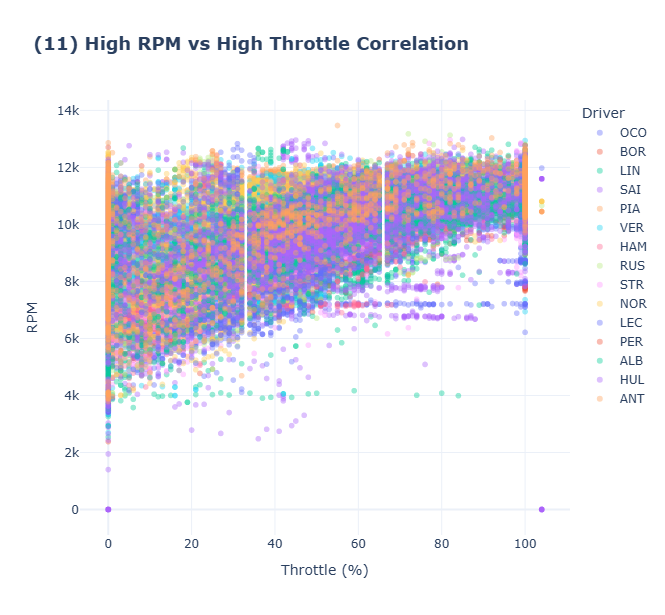

In [63]:
fig11 = px.scatter(
    data_frame=rpm_vs_throttle,
    x='throttle',
    y='rpm',
    color='driver_code',
    opacity=0.4,               # un po' trasparente perché ci sono tantissimi punti
    title='(11) High RPM vs High Throttle Correlation',
    labels={'throttle': 'Throttle (%)',
            'rpm': 'RPM',
            'driver_code': 'Driver'},
    width=1000,
    height=600
)

fig11.update_layout(
    title_font=dict(size=18, weight='bold'),
)

fig11.show()
# positive correlation between RPM and throttle (diagonal tendency)

#### (12) Average RPM Per Driver

###### Average RPM per driver across all laps — who consistently runs the highest engine speed?

In [64]:
avg_rpm = (final_df[final_df['gear'] > 0].groupby('driver_code')['rpm'].mean()).round(2).reset_index()
avg_rpm.rename(columns={'rpm': 'avg_rpm'}, inplace=True)
avg_rpm.sort_values('avg_rpm', ascending=False, inplace=True)
avg_rpm.reset_index(drop=True, inplace=True)

avg_rpm

,driver_code,avg_rpm
0,PIA,10254.27
1,ANT,10218.77
2,NOR,10166.30
3,RUS,10143.66
4,VER,10091.71
5,LEC,10031.38
6,ALB,10022.03
7,BOR,9963.04
8,SAI,9913.11
9,HUL,9899.75


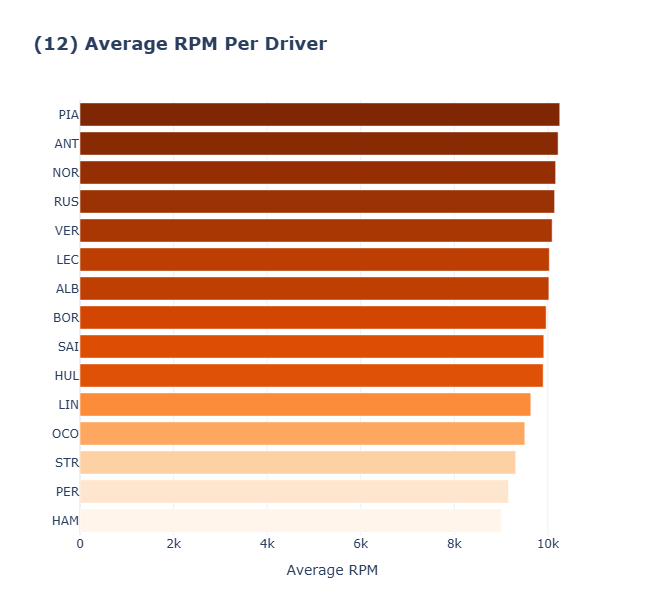

In [65]:
fig12 = px.bar(
    data_frame=avg_rpm,
    x='avg_rpm',
    y='driver_code',
    orientation='h',
    color='avg_rpm',
    color_continuous_scale=px.colors.sequential.Oranges,
    title='(12) Average RPM Per Driver',
    labels={'avg_rpm': 'Average RPM',
            'driver_code': ''},
    width=900,
    height=600
)

fig12.update_layout(
    title_font=dict(size=18, weight='bold'),
    coloraxis_showscale=False,
    yaxis=dict(categoryorder='total ascending')
)

fig12.show()

#### (13) RPM Distribution Per Gear

###### RPM distribution across each gear — how engine speed varies as drivers shift up

In [66]:
rpm_distribution_perGear = (final_df[final_df['gear'] > 0][['gear', 'rpm']]).reset_index(drop=True)

rpm_distribution_perGear

,gear,rpm
0,8,10818
1,8,10975
2,8,10936
3,8,10859
4,8,10763
...,...,...
112991,5,10950
112992,6,11081
112993,6,12108
112994,7,11309


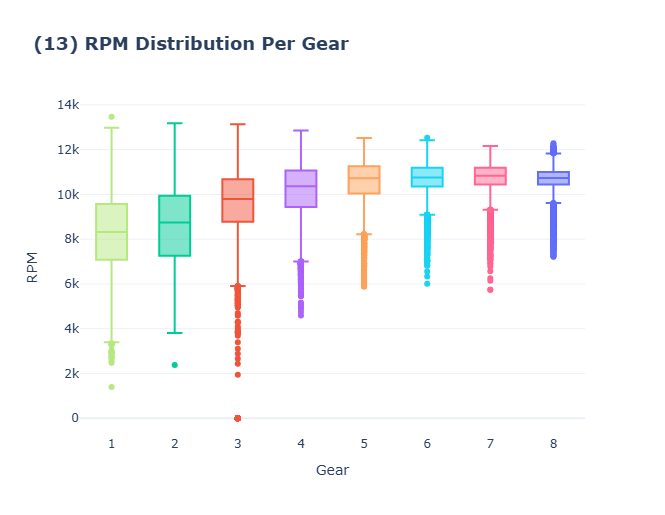

In [68]:
fig13 = px.box(
    data_frame=rpm_distribution_perGear,
    x='gear',
    y='rpm',
    color='gear',
    title='(13) RPM Distribution Per Gear',
    labels={'gear': 'Gear',
            'rpm': 'RPM'},
    width=900,
    height=500
)

fig13.update_layout(
    title_font=dict(size=18, weight='bold'),
    showlegend=False,
    xaxis=dict(tickmode='linear', dtick=1)
)

fig13.show()

### Group 5 — Cross-Variable Interactions & Mapping (14-15)

#### (14) Telemetry Correlation Heatmap

###### Correlation matrix of all numerical telemetry variables — speed, RPM, throttle, brake and gear

In [69]:
# columns we are focusing on
num_cols = ['speed', 'rpm', 'throttle', 'brake', 'gear', 'lap_time_sec_total']

# correlation matrix
corr_matrix = final_df[num_cols].corr().round(2)

corr_matrix

,speed,rpm,throttle,brake,gear,lap_time_sec_total
speed,1.00,0.83,0.43,-0.23,0.97,-0.29
rpm,0.83,1.00,0.28,-0.18,0.77,-0.33
throttle,0.43,0.28,1.00,-0.16,0.37,-0.04
brake,-0.23,-0.18,-0.16,1.00,-0.18,0.09
gear,0.97,0.77,0.37,-0.18,1.00,-0.28
lap_time_sec_total,-0.29,-0.33,-0.04,0.09,-0.28,1.00


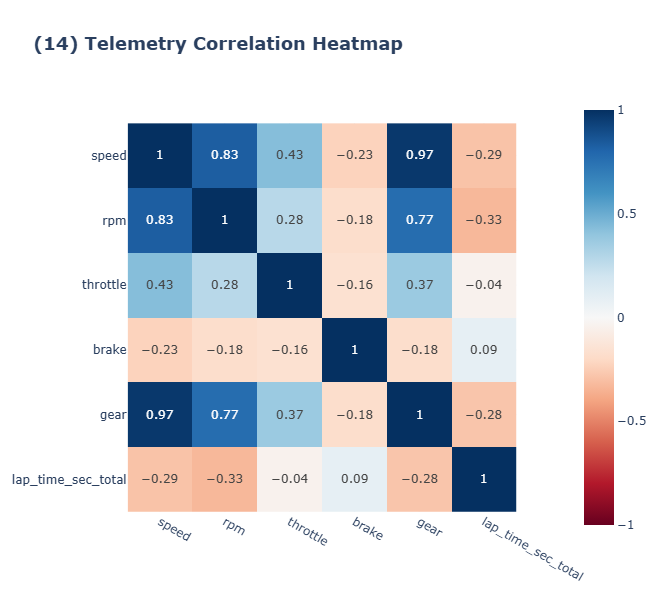

In [70]:
fig14 = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    title='(14) Telemetry Correlation Heatmap',
    width=700,
    height=600
)

fig14.update_layout(
    title_font=dict(size=18, weight='bold'),
)

fig14.show()

#### (15) Single-Lap Telemetry Profile


###### Second-by-second speed, RPM and throttle profile during each driver's fastest lap

In [71]:
telemetry_profile = (final_df[final_df['is_best_lap'] == True][['driver_code', 't', 'speed', 'rpm', 'throttle']]).reset_index(drop=True)

telemetry_profile

,driver_code,t,speed,rpm,throttle
0,OCO,0,292,11632,98
1,OCO,1,306,10817,99
2,OCO,2,317,11165,98
3,OCO,3,325,11390,99
4,OCO,4,327,11483,98
...,...,...,...,...,...
1756,ANT,93,220,11261,100
1757,ANT,94,249,11115,100
1758,ANT,95,261,11582,100
1759,ANT,96,266,10318,100


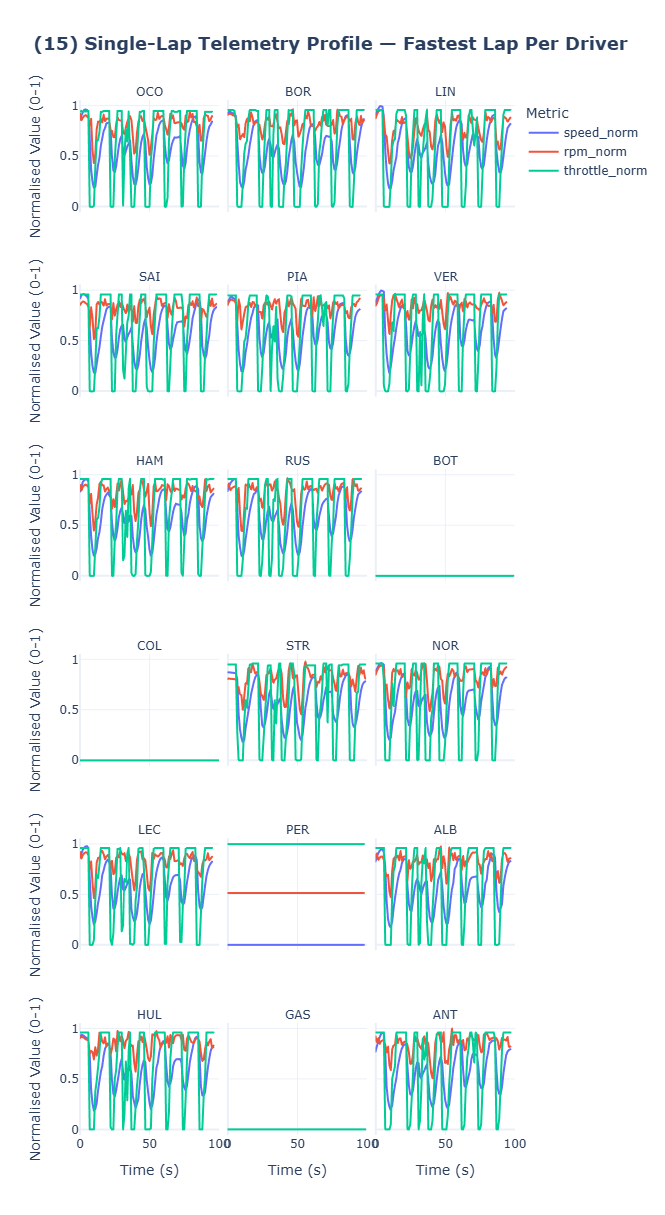

In [73]:
from sklearn.preprocessing import MinMaxScaler

# normalize between 0 and 1 for each metric
scaler = MinMaxScaler()
telemetry_profile[['speed_norm', 'rpm_norm', 'throttle_norm']] = scaler.fit_transform(
    telemetry_profile[['speed', 'rpm', 'throttle']]
)

# transform in long format
telemetry_long = pd.melt(
    telemetry_profile,
    id_vars=['driver_code', 't'],
    value_vars=['speed_norm', 'rpm_norm', 'throttle_norm'],
    var_name='metric',
    value_name='value'
)

fig15 = px.line(
    data_frame=telemetry_long,
    x='t',
    y='value',
    color='metric',
    facet_col='driver_code',
    facet_col_wrap=3,
    title='(15) Single-Lap Telemetry Profile — Fastest Lap Per Driver',
    labels={'t': 'Time (s)',
            'value': 'Normalised Value (0-1)',
            'metric': 'Metric',
            'driver_code': 'Driver'},
    width=1400,
    height=1200
)

fig15.update_layout(title_font=dict(size=18, weight='bold'))
fig15.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

fig15.show()

## Francesco Bovina
Data Analysis and Visualization with Python — TU Berlin, 2026